In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch_geometric

# from graphMatching import *
from matplotlib.patches import ConnectionPatch
from model_tg import *
from networkx import read_edgelist
from scipy.io import loadmat
from utils import *

In [35]:
print(torch_geometric.__version__)

np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

2.7.0


In [36]:
# !pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.1.0+cu121.html
# !pip install torch-geometric

In [37]:
data = "mentos" # args.dataset

device = torch.device('cuda:0' if torch.cuda.is_available() else "cpu")
train_features = {}
if (data == "ACM_DBLP"):
	train_set = ["ACM", "DBLP"]
	input_dim = 17
	b = np.load('data/ACM-DBLP.npz')
	train_features["ACM"] = [torch.from_numpy(b["x1"]).float()]
	train_features["DBLP"] = [torch.from_numpy(b["x2"]).float()]
	test_pairs = b['test_pairs'].astype(np.int32)
	NUM_HIDDEN_LAYERS = 12
	HIDDEN_DIM = [1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024]
	output_feature_size = 1024
	lr = 0.0001
	epoch = 100
elif (data == "Douban Online_Offline"):
	a1, f1, a2, f2, test_pairs = load_douban()
	f1 = f1.A
	f2 = f2.A
	train_set = ["Online", "Offline"]
	input_dim = 538
	test_pairs = torch.tensor(np.array(test_pairs, dtype=int)) - 1
	test_pairs = test_pairs.numpy()
	train_features["Online"] = [torch.from_numpy(f1).float()]
	train_features["Offline"] = [torch.from_numpy(f2).float()]
	NUM_HIDDEN_LAYERS = 6
	HIDDEN_DIM = [512,512,512,512,512,512,512]
	output_feature_size = 512
	lr = 0.0001
	epoch = 100
elif (data == "mentos"):
	train_set = [
		"Orange_1", "Orange_2",
		"Red_1", "Red_2",
		"Yellow_1", "Yellow_2",
	]
	input_dim = 3

	NUM_HIDDEN_LAYERS = 12
	HIDDEN_DIM = [1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024]
	output_feature_size = 3
	lr = 0.0001
	epoch = 100


In [38]:
""" temp = torch.from_numpy(b["x1"]).float() # G1, features
print(temp.shape)
temp """

' temp = torch.from_numpy(b["x1"]).float() # G1, features\nprint(temp.shape)\ntemp '

In [39]:
""" temp = torch.from_numpy(b["x2"]).float() # G2, features
print(temp.shape)
temp """

' temp = torch.from_numpy(b["x2"]).float() # G2, features\nprint(temp.shape)\ntemp '

In [40]:
""" temp = b["test_pairs"]
print(temp.shape)
temp """

' temp = b["test_pairs"]\nprint(temp.shape)\ntemp '

In [41]:
print("Loading training datasets")

train_loader = {}
train_features = {}
train_weights = {}
if data == "mentos":
	train_features_aux = {}
	for dataset in train_set:
		df_nodes = pd.read_csv("graphs_data/{}/nodes_{}.csv".format(data, dataset))
		train_features_aux[dataset] = df_nodes.iloc[:, 2:-1].values
		# idx,id,mz,rt,intensity_mean,intensity_cv

	train_loader_aux = {}
	train_weight_aux = {}
	for dataset in train_set:
		df_edges_data = pd.read_csv("graphs_data/{}/edges_{}.csv".format(data, dataset))
		train_loader_aux[dataset] = df_edges_data.iloc[:, [0, 1]].values
		train_weight_aux[dataset] = df_edges_data.iloc[:, 2].values

	# Construct adjacency matrices
	for dataset, features in train_features_aux.items():
		train_features[dataset] = [torch.from_numpy(features).float()]
	
	for dataset, weights in train_weight_aux.items():
		train_weights[dataset] = [torch.from_numpy(weights).float()]

	# train_loader = {}
	for dataset, loader in train_loader_aux.items():
		n = train_features[dataset][0].shape[0]
		matrix = torch.zeros(n, n)

		for item in loader:
			matrix[item[0]][item[1]] = 1
			matrix[item[1]][item[0]] = 1
		train_loader[dataset] = [matrix]
else:
	for dataset in train_set:
		train_loader[dataset] = [load_adj(dataset)]


Loading training datasets


##### Understand data (paper)

In [ ]:
adj_tensor = train_loader["ACM"][0]
print(adj_tensor.shape)
adj_tensor

In [ ]:
adj = coo_matrix(adj_tensor.numpy())
print(adj.shape)
adj

In [ ]:
adj_norm = preprocess_graph(adj)
print(len(adj_norm))
adj_norm

In [ ]:
adj_norm[0]

In [ ]:
adj_norm[1]

In [ ]:
adj_norm[2]

In [ ]:
adj_norm = torch.sparse.FloatTensor(torch.LongTensor(adj_norm[0].T),
									torch.FloatTensor(adj_norm[1]),
									torch.Size(adj_norm[2])).to(device)
print(adj_norm.shape)
adj_norm

In [ ]:
type(adj_norm)

In [ ]:
adj_norm

In [ ]:
# Transform data

adj_coo = adj_norm.coalesce()  # Asegurar formato COO
edge_index = adj_coo.indices() # [2, E]
edge_weight = adj_coo.values().view(-1, 1) # Fron [E] to [E,1]
edge_attr = torch.cat([
	edge_weight.abs(),         # strength
	torch.sign(edge_weight),   # direction (+1, -1)
	edge_weight ** 2           # nonlinearity
], dim=1)            # [E,3]

features = train_features["ACM"][0]
print(edge_index.shape)
print(edge_index)

print(edge_weight.shape)
print(edge_weight)

print(edge_attr.shape)
print(edge_attr)

print(features.shape)
print(features)

In [ ]:
# Remove this
"""
# reduce dimensions of node features
for item in train_features:
	feat = train_features[item][0]
	reduced_feat = feat[:, :3]  # Reduce to first 'input_dim' dimensions
	train_features[item][0] = reduced_feat
train_features """

In [ ]:
# Remove this
# PCA

"""
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

for item in train_features:
	feat = train_features[item][0]

	scaler = StandardScaler()
	X_scaled = scaler.fit_transform(feat)

	pca = PCA(n_components=3)
	X_pca = pca.fit_transform(X_scaled)

	train_features[item][0] = torch.from_numpy(X_pca).float()
train_features """

In [ ]:
train_features

In [ ]:
# Remove this
# Scaler

""" from sklearn.preprocessing import StandardScaler

for item in train_features:
	feat = train_features[item][0]

	scaler = StandardScaler()
	X_scaled = scaler.fit_transform(feat)

	train_features[item][0] = torch.from_numpy(X_scaled).float()
train_features """

##### Understand data (MS)

In [ ]:
train_set

In [ ]:
train_loader

In [ ]:
train_features

In [ ]:
train_weights

In [ ]:
train_weights["Orange_1"][0]

In [ ]:
len(train_loader["Orange_1"])

In [ ]:
for dataset in train_loader.keys():
	for i in range(len(train_loader[dataset])):
		print(dataset, i)

##### Train

In [45]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

for item in train_features:
	feat = train_features[item][0]

	scaler = StandardScaler()
	X_scaled = scaler.fit_transform(feat)

	train_features[item][0] = torch.from_numpy(X_scaled).float()
train_features 

{'Orange_1': [tensor([[ 2.5517, -2.1674, -6.4367],
          [-0.8679, -2.1329, -0.1573],
          [-0.6946, -2.1230, -0.1214],
          ...,
          [-0.3239,  1.7693,  0.0327],
          [-0.4626,  1.7702,  0.0483],
          [ 1.0981,  1.7735, -0.6132]])],
 'Orange_2': [tensor([[ 2.6120, -2.1791, -5.7248],
          [-0.2690, -2.1520, -0.3694],
          [-0.8701, -2.1444, -0.2968],
          ...,
          [-0.2688,  1.7620, -0.1022],
          [-0.2689,  1.7691, -0.0811],
          [-0.4574,  1.7775, -0.0189]])],
 'Red_1': [tensor([[-0.6446, -2.1626,  0.3116],
          [-0.2751, -2.1454, -0.8357],
          [-0.8654, -2.1379, -0.2030],
          ...,
          [-0.5756,  1.7690, -0.0634],
          [-0.3213,  1.7732,  0.0634],
          [ 1.1009,  1.7774, -0.6528]])],
 'Red_2': [tensor([[-0.6419, -2.1681, -0.2117],
          [-1.0041, -2.1665,  0.0622],
          [-0.2702, -2.1509, -0.4908],
          ...,
          [ 0.8345,  1.6447, -0.4005],
          [-0.7592,  1.6954, -0

In [46]:
# Init

encoder = "GIN" # Change GIN, GINE
epochs = 100 # remove
output_feature_size = 3 # remove
flag = True # remove

if encoder == "GIN":
	input_dim = 3
	GAE = TGAE_GIN(NUM_HIDDEN_LAYERS,
				input_dim,
				HIDDEN_DIM,
				output_feature_size).to(device)
elif encoder == "GINE":
	input_dim = 17 # Change 3

	""" for item in train_features:
		feat = train_features[item][0]
		reduced_feat = feat[:, :3]  # Reduce to first 'input_dim' dimensions
		train_features[item][0] = reduced_feat """

	GAE = TGAE_GINE(NUM_HIDDEN_LAYERS,
			input_dim,
			HIDDEN_DIM,
			output_feature_size).to(device)

In [47]:
print("Generating training features")
print("Fitting model", encoder)
print(train_set)
# fit_TGAE_subgraph(data, len(train_set) * (1 + 1), model, epoch, train_loader, train_features, device, lr,test_pairs)

# ---
no_samples = len(train_set) * (1 + 1)
# GAE = model
# ---

best_hitAtOne = 0
best_hitAtFive = 0
best_hitAtTen = 0
best_hitAtFifty = 0

optimizer = Adam(GAE.parameters(), lr=lr,weight_decay=5e-4)

counter = 0
best_loss = 1e9
patience = 15
losses = []

loop_obj = tqdm(range(1, epochs + 1))
for epoch in loop_obj:
	loop_obj.set_description(f"Epoch: {epoch}")
	
	loss = 0
	
	for dataset in train_loader.keys():
		S = train_loader[dataset][0]
		initial_features = train_features[dataset]
		# print(initial_features)
		for i in range(len(train_loader[dataset])):
			adj_tensor = train_loader[dataset][i]
			adj = coo_matrix(adj_tensor.numpy())
			adj_norm = preprocess_graph(adj)
			pos_weight = float(adj.shape[0] * adj.shape[0] - adj.sum()) / adj.sum()
			norm = adj.shape[0] * adj.shape[0] / float((adj.shape[0] * adj.shape[0] - adj.sum()) * 2)

			adj_label = coo_matrix(S.numpy())
			adj_label = sparse_to_tuple(adj_label)

			""" adj_norm = torch.sparse.FloatTensor(torch.LongTensor(adj_norm[0].T),
												torch.FloatTensor(adj_norm[1]),
												torch.Size(adj_norm[2])).to(device) """
			adj_norm = torch.sparse_coo_tensor(torch.LongTensor(adj_norm[0].T),
												torch.FloatTensor(adj_norm[1]),
												torch.Size(adj_norm[2])).to(device)

			adj_label = torch.sparse_coo_tensor(torch.LongTensor(adj_label[0].T),
												torch.FloatTensor(adj_label[1]),
												torch.Size(adj_label[2])).to(device)

			initial_feature = initial_features[i].to(device)

			weight_mask = adj_label.to_dense().view(-1) == 1
			weight_tensor = torch.ones(weight_mask.size(0))
			weight_tensor[weight_mask] = pos_weight
			weight_tensor = weight_tensor.to(device)
			
			# Transform data
			# This seccion is modified to adapt to the new GAE implementation
			adj_coo = adj_norm.coalesce()  # Asegurar formato COO
			edge_index = adj_coo.indices().long() # [2, E]
			## edge_weight = adj_coo.values().float().view(-1, 1) # [E,1]
			initial_weight = train_weights[dataset][i]
			edge_weight = initial_weight.view(-1, 1) # [E,1]

			edge_attr = torch.cat([
				edge_weight.abs(),         # strength
				torch.sign(edge_weight),   # direction (+1, -1)
				edge_weight ** 2           # nonlinearity
			], dim=1) # [E,3]

			if flag: # Show data shapes only once
				print("edge_index")
				print(edge_index.shape)
				print(edge_index)
				print()
				print("edge_weight")
				print(edge_weight.shape)
				print(edge_weight)
				print()
				print("edge_attr")
				print(edge_attr.shape)
				print(edge_attr)
				print()
				print("initial_feature")
				print(initial_feature.shape)
				print(initial_feature)
				flag = False

			if encoder == "GIN":
				z = GAE(initial_feature, edge_index)
			elif encoder == "GINE":
				z = GAE(initial_feature, edge_index, edge_weight)

			# z = GAE(initial_feature, adj_norm)
			A_pred = torch.sigmoid(torch.matmul(z, z.t()))
			loss += norm * F.binary_cross_entropy(A_pred.view(-1), adj_label.to_dense().view(-1),
														weight=weight_tensor)
			# loop_obj.set_postfix_str(f"Loss: {loss:.4f}")
	
	optimizer.zero_grad()
	loss = loss / no_samples
	loss.backward()
	optimizer.step()

	loop_obj.set_postfix_str(f"Loss: {loss:.4f}")

	losses.append(loss.item())
	if loss.item() < best_loss:
		best_loss = loss.item()
		counter = 0
	else:
		counter += 1
		if counter == patience:
			print("Early stopping, epoch: {}".format(epoch))
			break
	# ---
	""" keys = list(train_loader.keys())
	S1 = train_loader[keys[0]][0]
	S2 = train_loader[keys[1]][0]
	
	adj_S1 = coo_matrix(S1.numpy())
	adj_norm_1 = preprocess_graph(adj_S1)
	adj_norm_1 = torch.sparse.FloatTensor(torch.LongTensor(adj_norm_1[0].T),
											torch.FloatTensor(adj_norm_1[1]),
											torch.Size(adj_norm_1[2])).to(device)
	adj_S2 = coo_matrix(S2.numpy())
	adj_norm_2 = preprocess_graph(adj_S2)
	adj_norm_2 = torch.sparse.FloatTensor(torch.LongTensor(adj_norm_2[0].T),
											torch.FloatTensor(adj_norm_2[1]),
											torch.Size(adj_norm_2[2])).to(device)
	" "" if (data == "ACM_DBLP"):
		S1_feat = train_features["ACM"][0]
		S2_feat = train_features["DBLP"][0]
	elif (data == "Douban Online_Offline"):
		S1_feat = train_features["Online"][0]
		S2_feat = train_features["Offline"][0] " ""

	S1_feat = train_features[train_set[0]][0]
	S2_feat = train_features[train_set[1]][0]

	# ---
	adj_coo1 = adj_norm_1.coalesce()
	edge_index1 = adj_coo1.indices().long()
	edge_weight1 = adj_coo1.values().float().view(-1, 1)
	edge_attr1 = torch.cat([
		edge_weight1.abs(),         # strength
		torch.sign(edge_weight1),   # direction (+1, -1)
		edge_weight1 ** 2           # nonlinearity
	], dim=1) # [E,3]


	adj_coo2 = adj_norm_2.coalesce()
	edge_index2 = adj_coo2.indices().long()
	edge_weight2 = adj_coo2.values().float().view(-1, 1) # [E, 1] Change
	edge_attr2 = torch.cat([
		edge_weight2.abs(),         # strength
		torch.sign(edge_weight2),   # direction (+1, -1)
		edge_weight2 ** 2           # nonlinearity
	], dim=1) # [E,3]
	# ---

	# ---
	if encoder == "GIN":
		S1_emb = GAE(S1_feat.to(device), edge_index1).detach() # adj_norm_1).detach()
		S2_emb = GAE(S2_feat.to(device), edge_index2).detach() # adj_norm_2).detach()
	elif encoder == "GINE":
		S1_emb = GAE(S1_feat.to(device), edge_index1, edge_weight1).detach() # adj_norm_1).detach()
		S2_emb = GAE(S2_feat.to(device), edge_index2, edge_weight2).detach() # adj_norm_2).detach()

	D = torch.cdist(S1_emb, S2_emb, 2) # Euclidean distance
	
	if (data == "ACM_DBLP"):
		test_idx = test_pairs[:, 0].astype(np.int32)
		labels = test_pairs[:, 1].astype(np.int32)
	elif (data == "Douban Online_Offline"):
		test_idx = test_pairs[0, :].astype(np.int32)
		labels = test_pairs[1, :].astype(np.int32)
	
	hitAtOne = 0
	hitAtFive = 0
	hitAtTen = 0
	hitAtFifty = 0
	hitAtHundred = 0
	
	# test
	for i in range(len(test_idx)):
		dist_list = D[test_idx[i]]
		# print(i, test_idx[i], dist_list)
		sorted_neighbors = torch.argsort(dist_list).cpu()
		label = labels[i]
		
		" "" if i == 0:
			print(label, sorted_neighbors[0].item(), sorted_neighbors)
			# 6829 6829 tensor([6829, 3102,  601,  ..., 7878, 9701, 2044]) " ""
		
		for j in range(100):
			if (sorted_neighbors[j].item() == label):
				if (j == 0):
					hitAtOne += 1
					hitAtFive += 1
					hitAtTen += 1
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 4):
					hitAtFive += 1
					hitAtTen += 1
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 9):
					hitAtTen += 1
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 49):
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 100):
					hitAtHundred += 1
					break
	
	cur_hitAtOne = hitAtOne / len(test_idx)
	cur_hitAtFive = hitAtFive / len(test_idx)
	cur_hitAtTen = hitAtTen / len(test_idx)
	cur_hitAtFifty = hitAtFifty / len(test_idx)

	if(cur_hitAtOne > best_hitAtOne): best_hitAtOne = cur_hitAtOne
	if (cur_hitAtFive > best_hitAtFive): best_hitAtFive = cur_hitAtFive
	if (cur_hitAtTen > best_hitAtTen): best_hitAtTen = cur_hitAtTen
	if (cur_hitAtFifty > best_hitAtFifty): best_hitAtFifty = cur_hitAtFifty


print("The best results achieved:")
print("Hit@1: ", end="")
print(best_hitAtOne)
print("Hit@5: ", end="")
print(best_hitAtFive)
print("Hit@10: ", end="")
print(best_hitAtTen)
print("Hit@50: ", end="")
print(best_hitAtFifty) """

Generating training features
Fitting model GIN
['Orange_1', 'Orange_2', 'Red_1', 'Red_2', 'Yellow_1', 'Yellow_2']


Epoch: 1:   0%|          | 0/100 [00:00<?, ?it/s]

edge_index
torch.Size([2, 2199317])
tensor([[   0,    0,    0,  ..., 1778, 1778, 1778],
        [   0,    1,    2,  ..., 1776, 1777, 1778]], device='cuda:0')

edge_weight
torch.Size([1098769, 1])
tensor([[ 0.6754],
        [ 0.9323],
        [-0.9958],
        ...,
        [-0.8672],
        [-0.6263],
        [-0.9313]])

edge_attr
torch.Size([1098769, 3])
tensor([[ 0.6754,  1.0000,  0.4562],
        [ 0.9323,  1.0000,  0.8691],
        [ 0.9958, -1.0000,  0.9916],
        ...,
        [ 0.8672, -1.0000,  0.7520],
        [ 0.6263, -1.0000,  0.3923],
        [ 0.9313, -1.0000,  0.8674]])

initial_feature
torch.Size([1779, 3])
tensor([[ 2.5517, -2.1674, -6.4367],
        [-0.8679, -2.1329, -0.1573],
        [-0.6946, -2.1230, -0.1214],
        ...,
        [-0.3239,  1.7693,  0.0327],
        [-0.4626,  1.7702,  0.0483],
        [ 1.0981,  1.7735, -0.6132]], device='cuda:0')


Epoch: 27:  26%|██▌       | 26/100 [04:29<12:47, 10.37s/it, Loss: 0.3467]

Early stopping, epoch: 27


In [ ]:
train_set

In [ ]:
train_loader.keys()

In [48]:
# Get embeddings

dict_node_embeddings = {}

for dataset in train_set:
	S = train_loader[dataset][0]
	adj_S = coo_matrix(S.numpy())
	adj_norm = preprocess_graph(adj_S)
	adj_norm = torch.sparse_coo_tensor(torch.LongTensor(adj_norm[0].T),
											torch.FloatTensor(adj_norm[1]),
											torch.Size(adj_norm[2])).to(device)

	S_feat = train_features[dataset][0]
	# dict_feat[dataset] = S_feat

	# Transform data
	# This seccion is modified to adapt to the new GAE implementation
	adj_coo = adj_norm.coalesce()  # Asegurar formato COO
	edge_index = adj_coo.indices().long() # [2, E]
	## edge_weight = adj_coo.values().float().view(-1, 1) # [E,1]
	initial_weight = train_weights[dataset][0]
	edge_weight = initial_weight.view(-1, 1) # [E,1]

	edge_attr = torch.cat([
		edge_weight.abs(),         # strength
		torch.sign(edge_weight),   # direction (+1, -1)
		edge_weight ** 2           # nonlinearity
	], dim=1) # [E,3]

	if encoder == "GIN":
		S_emb = GAE(S_feat.to(device), edge_index).detach() # adj_norm_1).detach()
	elif encoder == "GINE":
		S_emb = GAE(S_feat.to(device), edge_index, edge_weight).detach() # adj_norm_1).detach()

	dict_node_embeddings[dataset] = S_emb.cpu().numpy()
dict_node_embeddings

{'Orange_1': array([[ 0.18232915, -0.1757463 , -0.5365436 ],
        [ 0.15702671,  0.14202432, -0.17446485],
        [ 0.14762731,  0.1336724 , -0.1731526 ],
        ...,
        [ 0.0248508 ,  0.27320027, -0.02934596],
        [ 0.03104863,  0.28132275, -0.02914735],
        [-0.0236253 ,  0.18514752, -0.07037932]], dtype=float32),
 'Orange_2': array([[ 0.1589326 , -0.16454694, -0.493664  ],
        [ 0.1347429 ,  0.10547129, -0.18852897],
        [ 0.161628  ,  0.13758384, -0.17933138],
        ...,
        [ 0.02687653,  0.26718193, -0.04023368],
        [ 0.02581279,  0.26807746, -0.03860756],
        [ 0.03217422,  0.2808338 , -0.03445066]], dtype=float32),
 'Red_1': array([[ 0.13272575,  0.13985835, -0.15137653],
        [ 0.14880218,  0.09512628, -0.21178006],
        [ 0.15762551,  0.14084671, -0.17728736],
        ...,
        [ 0.03985968,  0.28392607, -0.03348573],
        [ 0.02530286,  0.27282095, -0.02742203],
        [-0.02176154,  0.18303101, -0.07120575]], dtype=float

In [49]:
# Mapping idx, id (in node embeddings)
for dataset in train_set:
	df_nodes = pd.read_csv("graphs_data/{}/nodes_{}.csv".format(data, dataset))
	# idx,id,mz,rt,intensity_mean,intensity_cv

	df_node_embeddings = pd.DataFrame(dict_node_embeddings[dataset])
	df_node_embeddings.insert(0, "id", df_nodes["id"])
	dict_node_embeddings[dataset] = df_node_embeddings
dict_node_embeddings

{'Orange_1':         id         0         1         2
 0        4  0.182329 -0.175746 -0.536544
 1       33  0.157027  0.142024 -0.174465
 2       40  0.147627  0.133672 -0.173153
 3       50  0.155689  0.126817 -0.191757
 4       61  0.176004  0.111929 -0.226998
 ...    ...       ...       ...       ...
 1774  2277  0.009821  0.271886 -0.014817
 1775  2301  0.048976  0.278430 -0.050237
 1776  2304  0.024851  0.273200 -0.029346
 1777  2305  0.031049  0.281323 -0.029147
 1778  2306 -0.023625  0.185148 -0.070379
 
 [1779 rows x 4 columns],
 'Orange_2':         id         0         1         2
 0        4  0.158933 -0.164547 -0.493664
 1       24  0.134743  0.105471 -0.188529
 2       33  0.161628  0.137584 -0.179331
 3       50  0.153965  0.127195 -0.184220
 4       61  0.147103  0.132255 -0.175367
 ...    ...       ...       ...       ...
 1766  2281  0.051945  0.304410 -0.029386
 1767  2283  0.041138  0.285769 -0.036757
 1768  2289  0.026877  0.267182 -0.040234
 1769  2295  0.025813  0

##### Similarity analysis (KNN)

In [ ]:
train_set

In [ ]:
# Calculate distance matrix (KNN)
from sklearn.neighbors import NearestNeighbors

k = 1 # Change
knn = NearestNeighbors(n_neighbors=k, metric="euclidean")

first_dataset = train_set[0]
df_x = dict_node_embeddings[first_dataset]

df_alignment = pd.DataFrame()
df_alignment[first_dataset] = df_x["id"].values

for dataset in train_set[1:]:
	df_y = dict_node_embeddings[dataset]
	
	knn.fit(df_y.iloc[:, 1:])  # Exclude 'id' column
	distances, indices = knn.kneighbors(df_x.iloc[:, 1:])
	
	df_alignment[dataset] = df_y.loc[indices[:, 0]]["id"].values  # Only take the first neighbor
df_alignment

,Orange_1,Orange_2,Red_1,Red_2,Yellow_1,Yellow_2
0,4,4,2278,438,438,78
1,33,33,117,33,171,132
2,40,61,50,61,50,92
3,50,50,114,50,33,50
4,61,261,61,222,61,50
...,...,...,...,...,...,...
1774,2277,2249,2295,2249,2249,2249
1775,2301,2131,2178,2131,2083,2083
1776,2304,2304,2304,2304,2246,2156
1777,2305,2190,2112,2260,2150,2270


In [51]:
# Find node alignment 2 by 2
col1, col2 = train_set[:2] # Change
print(col1, col2)

df_alignment_filter = df_alignment[df_alignment.apply(lambda row: row[col1] == row[col2], axis=1)]
df_alignment_filter

Orange_1 Orange_2


,Orange_1,Orange_2,Red_1,Red_2,Yellow_1,Yellow_2
0,4,4,2278,438,438,78
1,33,33,117,33,171,132
3,50,50,114,50,33,50
12,125,125,125,125,125,28
20,154,154,210,298,154,154
...,...,...,...,...,...,...
1754,2187,2187,2187,2187,2187,2192
1758,2192,2192,2201,2192,2192,2187
1760,2201,2201,2274,2201,2201,2201
1767,2239,2239,2239,2133,2239,2300


In [52]:
# Find node alignment for all datasets
df_alignment[df_alignment.nunique(axis=1) == 1]

,Orange_1,Orange_2,Red_1,Red_2,Yellow_1,Yellow_2
824,1889,1889,1889,1889,1889,1889
879,2016,2016,2016,2016,2016,2016
1004,28,28,28,28,28,28
1039,297,297,297,297,297,297
1663,1819,1819,1819,1819,1819,1819


##### Plot

In [53]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# Concat
""" S_emb_cat = torch.cat(S_emb_aux, dim=0).cpu().numpy()
S_emb_cat """

""" if S_emb_cat.shape[1] > 3:
	pca = PCA(n_components=3)
	S_emb_cat = pca.fit_transform(S_emb_cat) """

In [ ]:
dict_node_embeddings

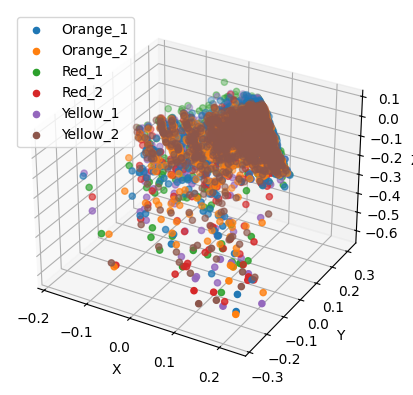

In [54]:
fig = plt.figure()
ax = fig.add_subplot(projection="3d")

# Separar clases
for dataset in train_set:
	df_node_embedding = dict_node_embeddings[dataset]
	X = df_node_embedding.iloc[:, 1].values
	Y = df_node_embedding.iloc[:, 2].values
	Z = df_node_embedding.iloc[:, 3].values
	ax.scatter(X, Y, Z, label=f"{dataset}")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()

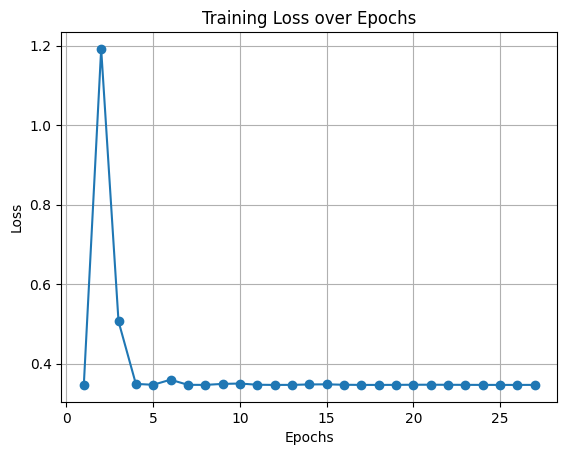

In [55]:
# Plot losses
plt.figure()
plt.plot(range(1, len(losses) + 1), losses, marker='o')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.show()

##### Similarity analysis (Hungarian)

In [ ]:
print(D.shape)
D

Truth

In [ ]:
print(data)
print(test_pairs.shape)
print(test_pairs)

In [ ]:
if (data == "ACM_DBLP"):
	test_pairs_ = test_pairs
elif (data == "Douban Online_Offline"):
	test_pairs_ = test_pairs.T
	
truth = test_pairs_[test_pairs_[:, 1].argsort()]
print(truth.shape)
truth

In [ ]:
truth_ = test_pairs_[test_pairs_[:, 0].argsort()]
print(truth_.shape)
truth_

#### Option 0

In [ ]:
def hungarian(D):
	print("0")
	P = torch.zeros_like(D)
	matrix = D.tolist()
	m = Munkres()
	print("1")
	indexes = m.compute(matrix)
	print("2")
	total = 0
	for r, c in tqdm(indexes):
		print(r)
		P[r][c] = 1
		total += matrix[r][c]
	return P.t()

X = hungarian(D)
print(X.shape)
# online_offline: 215m
# acm_dblp: 2112m
X

In [ ]:
# save

X = X.cpu().numpy()
np.save("P_hungarian_ACM_DBLP", X)

In [ ]:
# load

X = np.load("P_hungarian.npy")
X

In [ ]:
option0 = []
m, n = X.shape
for i in range(m):
	for j in range(n):
		if X[i][j] == 1:
			option0.append([j, i]) # S, S_hat
option0 = np.array(option0)
print(len(option0))
option0

In [ ]:
matching = test_matching(truth, option0)
print(len(matching))
print(len(matching) / len(truth))
matching

#### Option 1

In [ ]:
total_cost, assignments = hungarian_algorithm(D.cpu())

In [ ]:
option1 = np.array(assignments)
option1 = option1[option1[:, 1].argsort()]
print(option1.shape)
option1

In [ ]:
option1_ = option1[:, [1, 0]]
option1_

In [ ]:
matching = test_match(truth, option1)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)

plot_match(G1, G2, matching)

#### Option 2

In [ ]:
import pygmtools as pygm

X = pygm.hungarian(D.cpu().numpy())
print(X.shape)
X

In [ ]:
option2 = matrix_to_edge(X)
option2

In [ ]:
option2_ = option2[:, [1, 0]]
option2_

In [ ]:
matching = test_match(truth, option2)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

#### Option 3

In [ ]:
indices = []
for i in range(D.shape[0]):
	dist_list = D[i]
	sorted_neighbors = torch.argsort(dist_list).cpu()
	indices.append([i, sorted_neighbors[0]])

option3 = np.array(indices)
option3 = option3[option3[:, 1].argsort()]
print(option3.shape)
option3

In [ ]:
option3_ = option3[:, [1, 0]]
option3_

In [ ]:
matching = test_match(truth, option3)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

#### Option 4

In [ ]:
X = greedy_match(D)
X = X.todense()
X = np.array(X)
print(X.shape)
print(X)

In [ ]:
option4 = matrix_to_edge(X)
option4

In [ ]:
option4_ = option4[:, [1, 0]]
option4_

In [ ]:
matching = test_match(truth, option4)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

#### Option 5

In [ ]:
D_ = complete_to_square(D.cpu(), pad_value=100.0)
print(D_.shape)
D_

In [ ]:
D.shape

In [ ]:
# X = get_match(torch.tensor(D_), device)
X = get_match(D, device)
print(X.shape)
X

In [ ]:
option5 = matrix_to_edge(X)
option5

In [ ]:
option5_ = option5[:, [1, 0]]
option5_

In [ ]:
matching = test_match(truth, option5_) # ACM_DBLP (option5_)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

---

In [ ]:
a = torch.tensor([[0.0,  0.0], [0.0, 1.0], [0.0,  2.0]])
print(a)
b = torch.tensor([[0.0, 1.0 ], [1.0,  1.0]])
print(b)
torch.cdist(a, b, p=2)

In [ ]:
a = torch.tensor([[4.01, 3.0, 2.0, 0.1, 4.0]])
print(a)
torch.argsort(a, dim=1)

In [ ]:
a = np.array([[9, 2, 3],
			  [4, 5, 6],
			  [7, 0, 5]])

a[a[:, 2].argsort()]